##  Imports and Libraries

In [282]:
import os
import glob as gb
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter
from pathlib import Path
from PIL import Image
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.10.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Parameters & Dataset Paths

In [283]:

DATASET_ROOT = Path(r"C:\Users\nadee\Downloads\Emotion-Recognition\archive")

train_path = DATASET_ROOT / "train_new" #preprocessed & cleaned
test_path = DATASET_ROOT / "test_new"   #preprocessed & cleaned

#train_path = DATASET_ROOT / "train" #raw
#test_path = DATASET_ROOT / "test"   #raw

#train_path = DATASET_ROOT / "train_clean" #cleaned only
#test_path = DATASET_ROOT / "test_clean"   #cleaned only

if not train_path.is_dir():
    raise FileNotFoundError(f"Training folder not found: {train_path}\nRun the preprocessing notebook first or fix DATASET_ROOT.")
if not test_path.is_dir():
    raise FileNotFoundError(f"Testing folder not found: {test_path}\nRun the preprocessing notebook first or fix DATASET_ROOT.")

print("Train path:", train_path)
print("Test path:", test_path)
print("Training classes:", sorted(os.listdir(train_path)))
print("Testing classes:", sorted(os.listdir(test_path)))



#color_channels = 3   ###########################################
#height = 100
#width = 100

height = 48
width = 48
color_channels = 1
image_size = (height, width, color_channels)


num_classes = 6

batch_size = 64
epochs = 50
#epochs = 10


Train path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\train_new
Test path: C:\Users\nadee\Downloads\Emotion-Recognition\archive\test_new
Training classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Testing classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


##  Load Images Function

In [284]:
def load_image_from_new_folder(file_path):
    """
    Load the already-preprocessed image from train_new/test_new.
    No histogram, sharpening, denoising, or augmentation is applied here.
    Only resize safety + grayscale format + scale to 0-1 for model input.
    """
    try:
        image = Image.open(file_path).convert("L")  
        #image = Image.open(file_path).convert("RGB")    ###########################################
        image = image.resize((width, height))
        image = np.array(image, dtype="float32") / 255.0
        image = np.expand_dims(image, axis=-1)  # (48, 48) -> (48, 48, 1)
        return image
    except Exception as e:
        print(f"Could not read image: {file_path} | Error: {e}")
        return None


def read_data_from_folder(folder_path, desc="Loading Data"):
    images = []
    labels = []

    class_folders = sorted(os.listdir(folder_path))

    for folder in class_folders:
        class_path = os.path.join(folder_path, folder)

        if not os.path.isdir(class_path):
            continue

        files = []
        for ext in ["*.jpg", "*.jpeg", "*.png"]:
            files.extend(gb.glob(os.path.join(class_path, ext)))

        for file in tqdm(files, desc=f"{desc} - {folder}"):
            image = load_image_from_new_folder(file)

            if image is not None:
                images.append(image)
                labels.append(folder)

    return np.array(images), np.array(labels)


x_train, y_train = read_data_from_folder(str(train_path), desc="Training from train_new")
x_test, y_test = read_data_from_folder(str(test_path), desc="Testing from test_new")

#x_train, y_train = read_data_from_folder(str(train_path), desc="Training from train") #raw
#x_test, y_test = read_data_from_folder(str(test_path), desc="Testing from test")      #raw

#x_train, y_train = read_data_from_folder(str(train_path), desc="Training from train_clean") #cleaned only
#x_test, y_test = read_data_from_folder(str(test_path), desc="Testing from test_clean")    #cleaned only

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


Testing from test_new - surprised: 100%|██████████| 329/329 [00:00<00:00, 1460.25it/s]

x_train: (27772, 48, 48, 1)
x_test: (2908, 48, 48, 1)
y_train: (27772,)
y_test: (2908,)


##  Label Encoding

The labels are text, like `happy`, `sad`, and `angry`.

The CNN needs numerical labels, so we convert them to numbers, then to one-hot vectors.


In [285]:
# =========================
# Label Encoding and One-Hot Encoding
# =========================

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

# Convert text labels to integer labels
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Get class names and number of classes
class_names = list(label_encoder.classes_)
num_classes = len(class_names)

# Convert integer labels to one-hot encoding
y_train_encoded = to_categorical(y_train_int, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_int, num_classes=num_classes)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("y_train_encoded shape:", y_train_encoded.shape)
print("y_test_encoded shape:", y_test_encoded.shape)

Classes: ['angry', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Number of classes: 6
y_train_encoded shape: (27772, 6)
y_test_encoded shape: (2908, 6)


## Train-Validation Split

In [286]:
# =========================
# Train / Validation Split
# =========================

from sklearn.model_selection import train_test_split

x_train_split, x_val_split, y_train_split_encoded, y_val_split_encoded, y_train_split_int, y_val_split_int = train_test_split(
    x_train,
    y_train_encoded,
    y_train_int,
    test_size=0.2,
    random_state=42,
    stratify=y_train_int
)

validation_data = (x_val_split, y_val_split_encoded)

print("Training data:", x_train_split.shape, y_train_split_encoded.shape)
print("Validation data:", x_val_split.shape, y_val_split_encoded.shape)

Training data: (22217, 48, 48, 1) (22217, 6)
Validation data: (5555, 48, 48, 1) (5555, 6)


## Using Pre-Augmented Training Data

In [287]:
# No ImageDataGenerator here.
# We use the already-saved train_new images directly.

validation_data = (x_val_split, y_val_split_encoded)

print("Training data used directly:", x_train_split.shape, y_train_split_encoded.shape)
print("Validation data:", x_val_split.shape, y_val_split_encoded.shape)

Training data used directly: (22217, 48, 48, 1) (22217, 6)
Validation data: (5555, 48, 48, 1) (5555, 6)


##  Custom CNN 

In [288]:
def create_custom_cnn(image_size, num_classes):
    model = tf.keras.Sequential([
        layers.Input(shape=image_size),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu", kernel_initializer="he_normal"),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Flatten(),

        layers.Dense(256,activation="relu",kernel_initializer="he_normal",kernel_regularizer=l2(0.0005)),#############################

        layers.Dropout(0.50),
        layers.Dense(num_classes, activation="softmax")


    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    model.summary()
    return model


single_model = create_custom_cnn(image_size, num_classes)


Model: "sequential_20"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_120 (Conv2D)         (None, 48, 48, 32)        320       
                                                                 
 conv2d_121 (Conv2D)         (None, 48, 48, 32)        9248      
                                                                 
 max_pooling2d_60 (MaxPoolin  (None, 24, 24, 32)       0         
 g2D)                                                            
                                                                 
 dropout_80 (Dropout)        (None, 24, 24, 32)        0         
                                                                 
 conv2d_122 (Conv2D)         (None, 24, 24, 64)        18496     
                                                                 
 conv2d_123 (Conv2D)         (None, 24, 24, 64)        36928     
                                                     

In [289]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=12,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_fer2013_cnn_model_train_new.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history = single_model.fit(
    x_train_split,
    y_train_split_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=validation_data,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


# =========================
# Evaluation Metrics
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)
from tensorflow.keras.utils import to_categorical
import numpy as np
import os
import tensorflow as tf

# =========================
# Evaluation Metrics
# =========================

best_model_path = "best_fer2013_cnn_model_train_new.h5"

if os.path.exists(best_model_path):
    print("Loading best checkpoint:", best_model_path)
    evaluation_model = tf.keras.models.load_model(best_model_path)
else:
    print("Best checkpoint not found; using current model.")
    evaluation_model = single_model

# Predict probabilities
y_pred_prob = evaluation_model.predict(x_test)

# Convert probabilities to class numbers
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = y_test_int

# One-hot true labels for ROC-AUC
y_true_one_hot = to_categorical(y_true, num_classes=len(class_names))

# Classification report
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
))

# Main metrics
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true_one_hot,
    y_pred_prob,
    average="weighted",
    multi_class="ovr"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("ROC-AUC:", roc_auc)


Epoch 1/50
348/348 [==============================] - ETA: 0s - loss: 1.9605 - accuracy: 0.2244
Epoch 1: val_accuracy improved from -inf to 0.47183, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 6s 15ms/step - loss: 1.9605 - accuracy: 0.2244 - val_loss: 1.5826 - val_accuracy: 0.4718 - lr: 0.0010
Epoch 2/50
347/348 [============================>.] - ETA: 0s - loss: 1.3866 - accuracy: 0.5210
Epoch 2: val_accuracy improved from 0.47183 to 0.63420, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 5s 13ms/step - loss: 1.3867 - accuracy: 0.5210 - val_loss: 1.1001 - val_accuracy: 0.6342 - lr: 0.0010
Epoch 3/50
348/348 [==============================] - ETA: 0s - loss: 1.1173 - accuracy: 0.6328
Epoch 3: val_accuracy improved from 0.63420 to 0.70927, saving model to best_fer2013_cnn_model_train_new.h5
348/348 [==============================] - 4s 13ms/step - loss: 1.1173 - accuracy: 0.6328 - val_loss:

## Class Distribution

Training class distribution:
angry: 4600
fearful: 4600
happy: 4772
neutral: 4600
sad: 4600
surprised: 4600


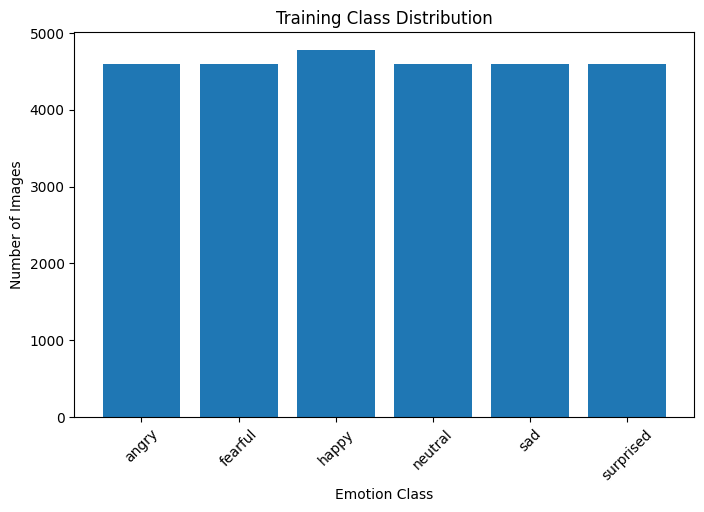

In [290]:
from collections import Counter
import matplotlib.pyplot as plt

class_counts = Counter(y_train)

print("Training class distribution:")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Training Class Distribution")
plt.xlabel("Emotion Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

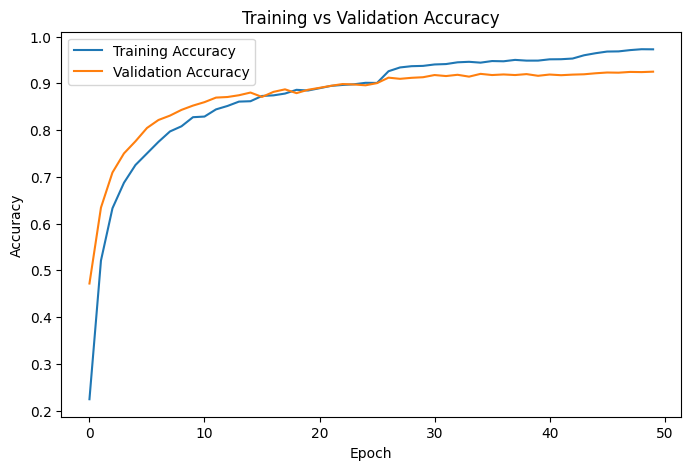

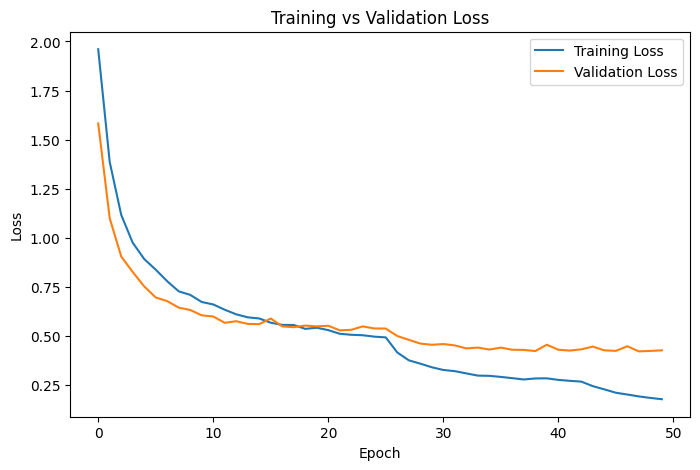

In [291]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


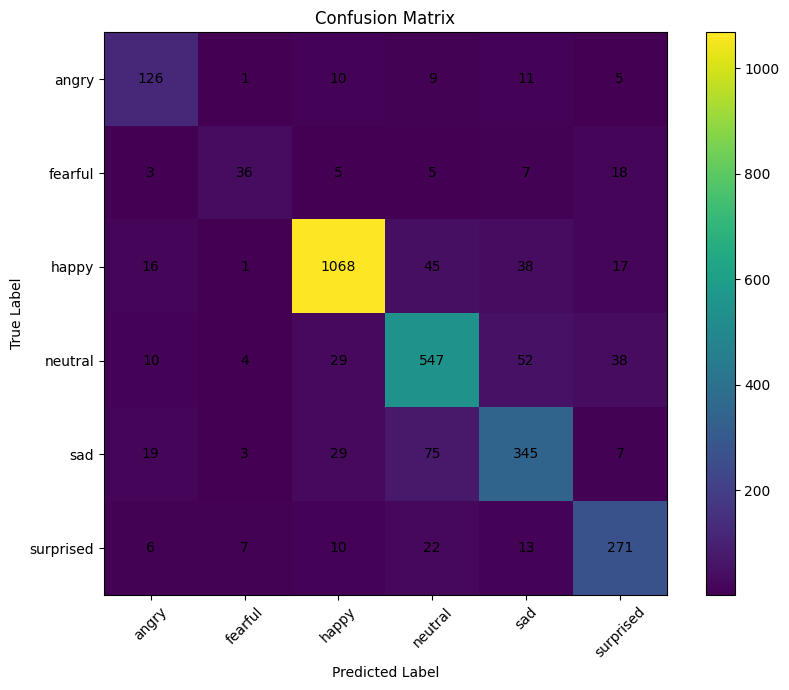

In [292]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()


91/91 [==============================] - 0s 4ms/step


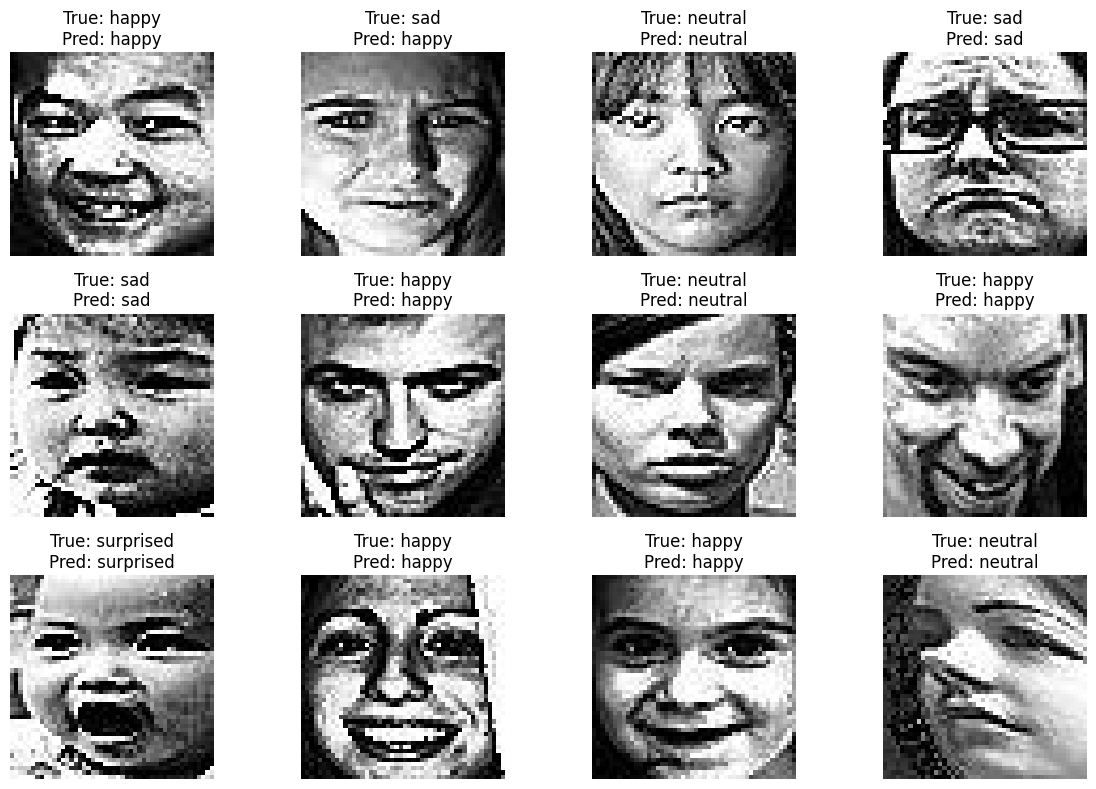

In [293]:
# =========================
# Sample Predictions - Random Samples
# =========================

import matplotlib.pyplot as plt
import numpy as np

# Make predictions
y_pred_probs = single_model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# True labels are already integer encoded
y_true_labels = y_test_int

# Choose 12 random test images every time
random_indexes = np.random.choice(len(x_test), size=12, replace=False)

plt.figure(figsize=(12, 8))

for plot_i, data_i in enumerate(random_indexes):
    plt.subplot(3, 4, plot_i + 1)
    plt.imshow(x_test[data_i].squeeze(), cmap="gray")

    true_label = label_encoder.inverse_transform([y_true_labels[data_i]])[0]
    pred_label = label_encoder.inverse_transform([y_pred_labels[data_i]])[0]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualize Training Samples

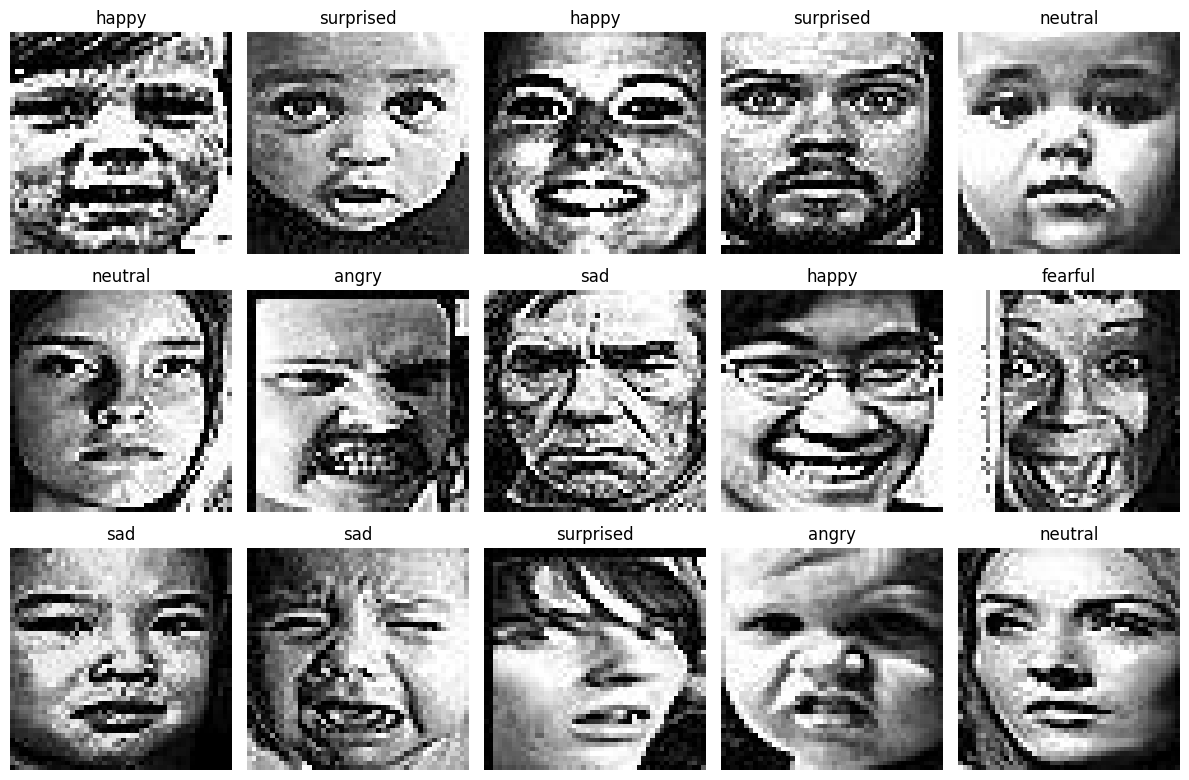

In [294]:
def visualize_data(images, labels, rows=3, cols=5):
    plt.figure(figsize=(12, 8))

    random_indexes = np.random.randint(0, len(images), rows * cols)

    for n, i in enumerate(random_indexes):
        plt.subplot(rows, cols, n + 1)
        plt.imshow(images[i].squeeze(), cmap="gray")
        plt.axis("off")
        plt.title(labels[i])

    plt.tight_layout()
    plt.show()


visualize_data(x_train, y_train)
